# HDP00049 — Secondary Analysis: AnalyzedData-tables

**Data source:** `AnalyzedData-tables.csv`  
**Design:** Preclinical study — 63 rats across two conditions (AC = Adversity Condition, SR = Stress Resilient) and two sexes (M/F), spanning 9 experimental runs (Op1–Op9).  
**Domains:** Opioid self-administration (lever presses), pain sensitivity (Dry Ice, Von Frey, Hargreaves), HPA-axis stress hormones (ACTH, Corticosterone AUC & time-course), and open-field locomotion/anxiety.

---

### Contents
1. Setup & Data Load  
2. Sample Overview  
3. Opioid Self-Administration & Reinstatement  
4. Pain Sensitivity (Baseline vs. Experimental)  
5. HPA-Axis: Corticosterone & ACTH AUC  
6. HPA-Axis: Hormone Time-Course Profiles  
7. Open-Field Behavior  
8. Heatmap — Measure Summary by Group  
9. Baseline vs. Experimental Δ Change Summary  
10. Summary Table & Export  

## 1. Setup & Data Load

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Palette ──────────────────────────────────────────────────────────────────
C = {
    'AC_M':  '#1D4ED8',   # blue
    'AC_F':  '#7C3AED',   # purple
    'SR_M':  '#0D9488',   # teal
    'SR_F':  '#D97706',   # amber
    'AC':    '#2563EB',
    'SR':    '#0D9488',
    'M':     '#1E40AF',
    'F':     '#BE185D',
}
sns.set_theme(style='whitegrid', font_scale=1.05)

DATA_PATH = 'AnalyzedData-tables.csv'   # update path if needed

df = pd.read_csv(DATA_PATH)

# Convenience: group label
df['Group'] = df['Condition'] + '_' + df['Sex']

print(f'Rows loaded : {len(df)}')
print(f'Columns     : {df.shape[1]}')
print(f'\nMissing values per column:')
miss = df.isna().sum()
print(miss[miss > 0].to_string())

Rows loaded : 63
Columns     : 45

Missing values per column:
Extinction 1 (Active Lever Presses)                1
Footshock Reinstatement (Active Lever Presses)     1
Dry Ice Exp                                        1
Hargreaves BSLN                                   22
Hargreaves Exp                                     6
Baseline ACTH Diurnal PM                           1
Baseline ACTH 60 min                               2
Baseline ACTH 90 min                               1
Baseline ACTH 150 min                              3
Exp. ACTH Diurnal PM                               6
Exp. ACTH Diurnal AM = 0 min                       3
Exp. ACTH 30 min                                   3
Exp. ACTH 60 min                                   2
Exp. ACTH 90 min                                   1
Exp. ACTH 150 min                                  1
Exp. Cort 60 min                                   1
Exp. Cort 90 min                                   1
Exp. Cort 150 min                    

## 2. Sample Overview

In [2]:
# ── N per group ───────────────────────────────────────────────────────────────
n_table = df.groupby(['Condition','Sex']).size().unstack(fill_value=0)
n_table['Total'] = n_table.sum(axis=1)
n_table.loc['Total'] = n_table.sum()
print('Sample size by Condition × Sex')
display(n_table)

print('\nRuns (Ops) in dataset:')
display(df.groupby('Run')[['Condition','Sex']].agg(lambda x: ', '.join(sorted(x.unique()))))

Sample size by Condition × Sex


Sex,F,M,Total
Condition,,,
AC,15,16,31
SR,16,16,32
Total,31,32,63



Runs (Ops) in dataset:


,Condition,Sex
Run,,
Op1,"AC, SR",M
Op2,"AC, SR",M
Op3,"AC, SR",M
Op4,"AC, SR",M
Op5,"AC, SR",F
Op6,"AC, SR",F
Op7,"AC, SR",F
Op8,SR,F
Op9,"AC, SR",F


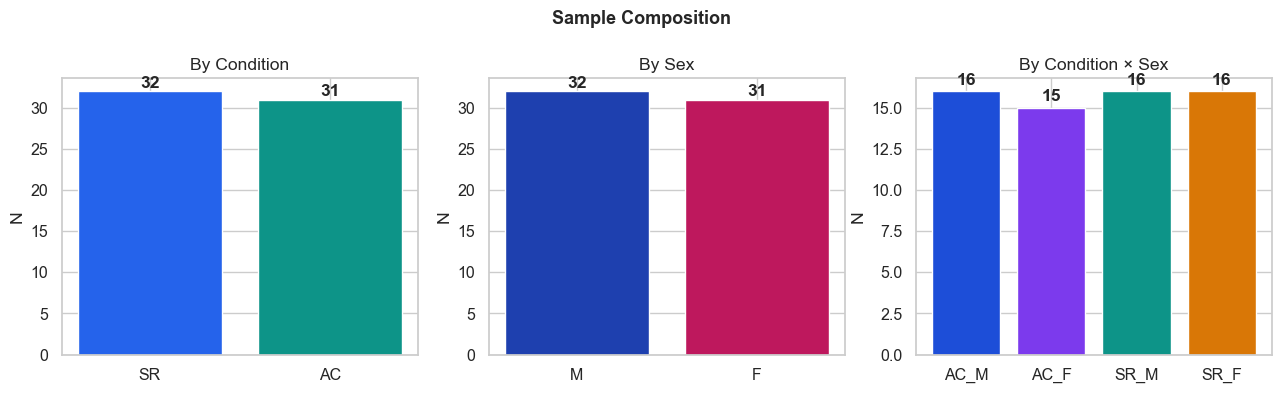

In [3]:
# ── Sample composition chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Sample Composition', fontsize=13, fontweight='bold')

# Condition
cond_c = df['Condition'].value_counts()
axes[0].bar(cond_c.index, cond_c.values, color=[C['AC'], C['SR']])
axes[0].set_title('By Condition'); axes[0].set_ylabel('N')
for i, v in enumerate(cond_c.values):
    axes[0].text(i, v+0.4, str(v), ha='center', fontweight='bold')

# Sex
sex_c = df['Sex'].value_counts()
axes[1].bar(sex_c.index, sex_c.values, color=[C['M'], C['F']])
axes[1].set_title('By Sex'); axes[1].set_ylabel('N')
for i, v in enumerate(sex_c.values):
    axes[1].text(i, v+0.4, str(v), ha='center', fontweight='bold')

# Group (Condition × Sex)
grp_c = df['Group'].value_counts().reindex(['AC_M','AC_F','SR_M','SR_F'])
bars = axes[2].bar(grp_c.index, grp_c.values, color=[C['AC_M'],C['AC_F'],C['SR_M'],C['SR_F']])
axes[2].set_title('By Condition × Sex'); axes[2].set_ylabel('N')
for bar, v in zip(bars, grp_c.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.4, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_sample.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Opioid Self-Administration & Reinstatement

Two behavioral measures:
- **Extinction 1** — active lever presses during extinction (lower = better extinction learning)
- **Footshock Reinstatement** — lever presses following footshock-induced reinstatement (higher = greater relapse-like responding)

In [4]:
lever_cols = ['Extinction 1 (Active Lever Presses)', 'Footshock Reinstatement (Active Lever Presses)']

lever_stats = df.groupby(['Condition','Sex'])[lever_cols].agg(['mean','std','count'])
print('Lever Press Means (SD) by Group')
display(lever_stats)

# Mann-Whitney U tests: AC vs SR within each sex, for each measure
print('\n── Mann-Whitney U: AC vs SR ──')
for col in lever_cols:
    for sex in ['M','F']:
        a = df[(df['Condition']=='AC')&(df['Sex']==sex)][col].dropna()
        b = df[(df['Condition']=='SR')&(df['Sex']==sex)][col].dropna()
        if len(a)>2 and len(b)>2:
            u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
            print(f'  {col[:40]:42s} | {sex} | U={u:.0f}, p={p:.3f}')

Lever Press Means (SD) by Group


Extinction 1 (Active Lever Presses)               \
                                             mean    std count   
Condition Sex                                                    
AC        F                                165.33 115.66    15   
          M                                 82.47  41.73    15   
SR        F                                142.12  85.22    16   
          M                                 74.19  32.30    16   

              Footshock Reinstatement (Active Lever Presses)              
                                                        mean   std count  
Condition Sex                                                             
AC        F                                            32.33 22.31    15  
          M                                            11.07  8.57    15  
SR        F                                            45.50 40.60    16  
          M                                            17.75 14.81    16


── Mann-Whitney U: AC vs SR ──
  Extinction 1 (Active Lever Presses)        | M | U=138, p=0.489
  Extinction 1 (Active Lever Presses)        | F | U=131, p=0.678
  Footshock Reinstatement (Active Lever Pr   | M | U=85, p=0.171
  Footshock Reinstatement (Active Lever Pr   | F | U=111, p=0.737


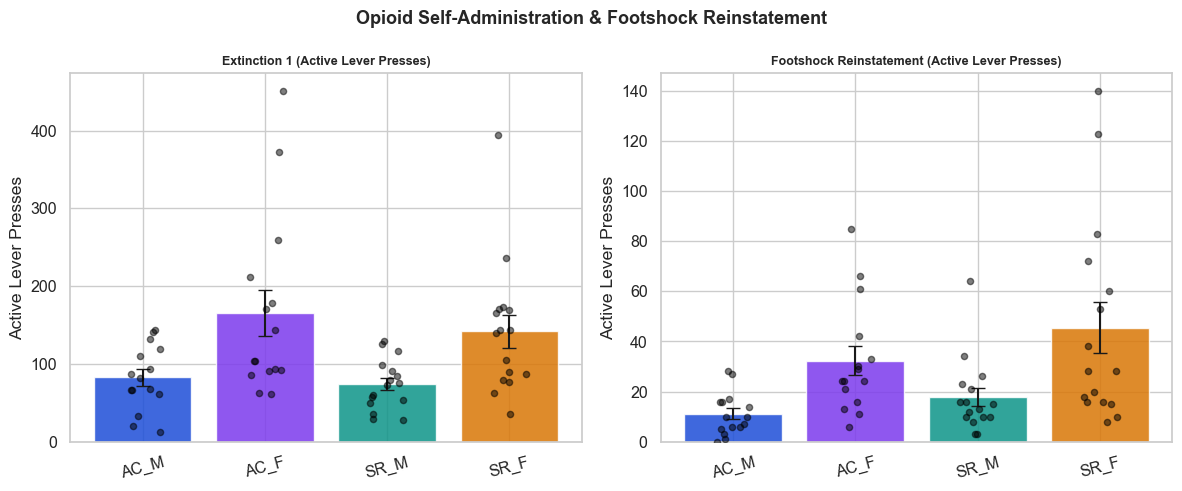

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Opioid Self-Administration & Footshock Reinstatement', fontsize=13, fontweight='bold')

groups_order = ['AC_M','AC_F','SR_M','SR_F']
group_colors = [C[g] for g in groups_order]

for ax, col in zip(axes, lever_cols):
    means = [df[df['Group']==g][col].mean() for g in groups_order]
    sems  = [df[df['Group']==g][col].sem()  for g in groups_order]
    bars = ax.bar(groups_order, means, yerr=sems, capsize=5,
                  color=group_colors, alpha=0.85, error_kw={'linewidth':1.5})
    # Overlay individual points
    for i, g in enumerate(groups_order):
        vals = df[df['Group']==g][col].dropna()
        ax.scatter(np.full(len(vals), i) + np.random.uniform(-0.15, 0.15, len(vals)),
                   vals, color='black', s=20, alpha=0.5, zorder=3)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('Active Lever Presses')
    ax.set_xticklabels(groups_order, rotation=15)

plt.tight_layout()
plt.savefig('fig_lever.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Pain Sensitivity (Baseline vs. Experimental)

Three pain assays measured at baseline and after experimental manipulation:
- **Dry Ice** — cold hypersensitivity threshold (seconds; higher = less sensitive)
- **Von Frey** — mechanical threshold (mN; higher = less sensitive)
- **Hargreaves** — thermal withdrawal latency (seconds; higher = less sensitive)

In [6]:
pain_pairs = {
    'Dry Ice (s)':         ('Dry Ice BSLN',          'Dry Ice Exp'),
    'Von Frey (mN)':       ('Von BSLN force in mN',  'Von Exp force in mN'),
    'Hargreaves (s)':      ('Hargreaves BSLN',        'Hargreaves Exp'),
}

print('Pain Sensitivity — Mean (SD) by Group')
rows = []
for assay, (bsln_col, exp_col) in pain_pairs.items():
    for g in groups_order:
        sub = df[df['Group']==g]
        b = sub[bsln_col].dropna()
        e = sub[exp_col].dropna()
        rows.append({
            'Assay': assay, 'Group': g,
            'Baseline Mean (SD)': f"{b.mean():.2f} ({b.std():.2f})" if len(b) else 'N/A',
            'Exp. Mean (SD)':     f"{e.mean():.2f} ({e.std():.2f})" if len(e) else 'N/A',
            'Δ (Exp−BSLN)':      f"{(e.mean()-b.mean()):.2f}" if len(b) and len(e) else 'N/A',
        })
pain_df = pd.DataFrame(rows).set_index(['Assay','Group'])
display(pain_df)

# Wilcoxon signed-rank: BSLN vs Exp within each group
print('\n── Wilcoxon signed-rank: Baseline vs Experimental (within group) ──')
for assay, (bsln_col, exp_col) in pain_pairs.items():
    for g in groups_order:
        sub = df[df['Group']==g][[bsln_col, exp_col]].dropna()
        if len(sub) >= 4:
            stat, p = stats.wilcoxon(sub[bsln_col], sub[exp_col])
            print(f'  {assay:20s} | {g:6s} | W={stat:.0f}, p={p:.3f}')

Pain Sensitivity — Mean (SD) by Group


Baseline Mean (SD) Exp. Mean (SD) Δ (Exp−BSLN)
Assay          Group                                               
Dry Ice (s)    AC_M        16.97 (1.59)   14.53 (2.65)        -2.44
               AC_F        16.86 (1.67)   15.02 (1.30)        -1.84
               SR_M        16.48 (1.94)   15.15 (1.99)        -1.32
               SR_F        16.84 (1.66)   15.77 (1.75)        -1.07
Von Frey (mN)  AC_M       79.35 (26.20)  28.19 (13.15)       -51.15
               AC_F       31.31 (17.66)  25.97 (17.02)        -5.34
               SR_M       79.31 (41.14)  35.92 (21.33)       -43.39
               SR_F       36.23 (21.66)   21.22 (5.48)       -15.01
Hargreaves (s) AC_M        13.61 (1.26)   15.72 (3.37)         2.11
               AC_F        12.81 (2.48)   15.65 (1.95)         2.84
               SR_M        12.51 (0.37)   16.32 (2.84)         3.82
               SR_F        14.51 (2.13)   12.29 (2.01)        -2.22


── Wilcoxon signed-rank: Baseline vs Experimental (within group) ──
  Dry Ice (s)          | AC_M   | W=11, p=0.003
  Dry Ice (s)          | AC_F   | W=7, p=0.001
  Dry Ice (s)          | SR_M   | W=32, p=0.065
  Dry Ice (s)          | SR_F   | W=32, p=0.065
  Von Frey (mN)        | AC_M   | W=0, p=0.000
  Von Frey (mN)        | AC_F   | W=15, p=0.109
  Von Frey (mN)        | SR_M   | W=13, p=0.003
  Von Frey (mN)        | SR_F   | W=0, p=0.003
  Hargreaves (s)       | AC_M   | W=5, p=0.312
  Hargreaves (s)       | AC_F   | W=8, p=0.002
  Hargreaves (s)       | SR_M   | W=4, p=0.875
  Hargreaves (s)       | SR_F   | W=20, p=0.011


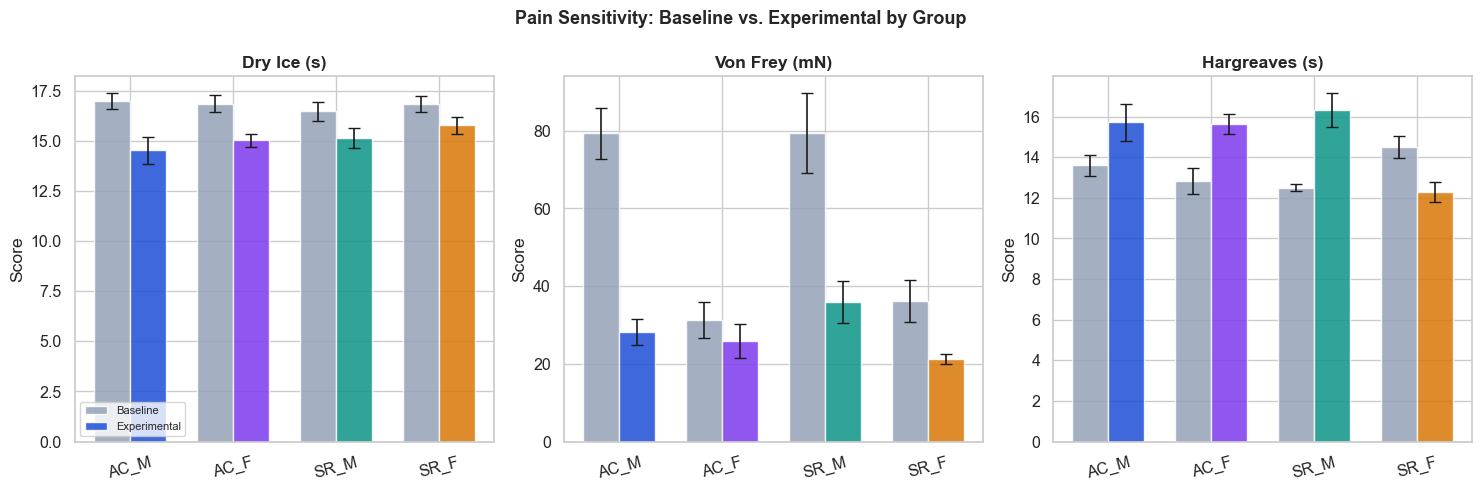

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Pain Sensitivity: Baseline vs. Experimental by Group', fontsize=13, fontweight='bold')

x = np.arange(len(groups_order))
width = 0.35

for ax, (assay, (bsln_col, exp_col)) in zip(axes, pain_pairs.items()):
    means_b = [df[df['Group']==g][bsln_col].mean() for g in groups_order]
    means_e = [df[df['Group']==g][exp_col].mean()  for g in groups_order]
    sems_b  = [df[df['Group']==g][bsln_col].sem()  for g in groups_order]
    sems_e  = [df[df['Group']==g][exp_col].sem()   for g in groups_order]

    b1 = ax.bar(x - width/2, means_b, width, yerr=sems_b, capsize=4,
                label='Baseline', color='#94A3B8', alpha=0.85, error_kw={'linewidth':1.2})
    b2 = ax.bar(x + width/2, means_e, width, yerr=sems_e, capsize=4,
                label='Experimental', color=group_colors, alpha=0.85, error_kw={'linewidth':1.2})

    ax.set_title(assay, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(groups_order, rotation=15)
    ax.set_ylabel('Score')
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_pain.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. HPA-Axis: Corticosterone & ACTH AUC

Area under the curve (AUC) integrates the full stress hormone response. Compared at baseline and post-experimental manipulation.

In [8]:
auc_pairs = {
    'Corticosterone AUC': ('Baseline Cort AUC', 'Exp. Cort AUC'),
    'ACTH AUC':           ('Baseline ACTH AUC', 'Exp. ACTH AUC'),
}

print('HPA-Axis AUC — Mean (SD) by Group')
auc_rows = []
for hormone, (bsln_col, exp_col) in auc_pairs.items():
    for g in groups_order:
        sub = df[df['Group']==g]
        b = sub[bsln_col].dropna()
        e = sub[exp_col].dropna()
        auc_rows.append({
            'Hormone': hormone, 'Group': g,
            'Baseline Mean (SD)': f"{b.mean():.1f} ({b.std():.1f})" if len(b) else 'N/A',
            'Exp. Mean (SD)':     f"{e.mean():.1f} ({e.std():.1f})" if len(e) else 'N/A',
            'Δ (Exp−BSLN)':      f"{(e.mean()-b.mean()):.1f}" if len(b) and len(e) else 'N/A',
        })
display(pd.DataFrame(auc_rows).set_index(['Hormone','Group']))

print('\n── Wilcoxon signed-rank: Baseline vs Experimental AUC (within group) ──')
for hormone, (bsln_col, exp_col) in auc_pairs.items():
    for g in groups_order:
        sub = df[df['Group']==g][[bsln_col, exp_col]].dropna()
        if len(sub) >= 4:
            stat, p = stats.wilcoxon(sub[bsln_col], sub[exp_col])
            direction = '↓' if sub[exp_col].mean() < sub[bsln_col].mean() else '↑'
            print(f'  {hormone:25s} | {g:6s} | W={stat:.0f}, p={p:.3f}  {direction}')

HPA-Axis AUC — Mean (SD) by Group


Baseline Mean (SD)     Exp. Mean (SD) Δ (Exp−BSLN)
Hormone            Group                                                   
Corticosterone AUC AC_M   65627.7 (14608.1)  51624.3 (26932.7)     -14003.4
                   AC_F   55858.7 (19657.9)  36722.1 (10828.8)     -19136.6
                   SR_M   68940.0 (19797.5)   35320.5 (8885.4)     -33619.5
                   SR_F   52748.1 (15215.8)  36868.6 (14476.9)     -15879.4
ACTH AUC           AC_M   55021.9 (36984.4)  37340.0 (29013.8)     -17681.9
                   AC_F   14590.2 (12446.1)    7587.2 (5564.5)      -7003.0
                   SR_M   68128.0 (51043.1)  29417.1 (15781.9)     -38710.9
                   SR_F   17842.1 (11495.5)   10900.4 (8184.9)      -6941.7


── Wilcoxon signed-rank: Baseline vs Experimental AUC (within group) ──
  Corticosterone AUC        | AC_M   | W=15, p=0.008  ↓
  Corticosterone AUC        | AC_F   | W=5, p=0.001  ↓
  Corticosterone AUC        | SR_M   | W=0, p=0.000  ↓
  Corticosterone AUC        | SR_F   | W=15, p=0.004  ↓
  ACTH AUC                  | AC_M   | W=25, p=0.048  ↓
  ACTH AUC                  | AC_F   | W=15, p=0.033  ↓
  ACTH AUC                  | SR_M   | W=6, p=0.003  ↓
  ACTH AUC                  | SR_F   | W=2, p=0.001  ↓


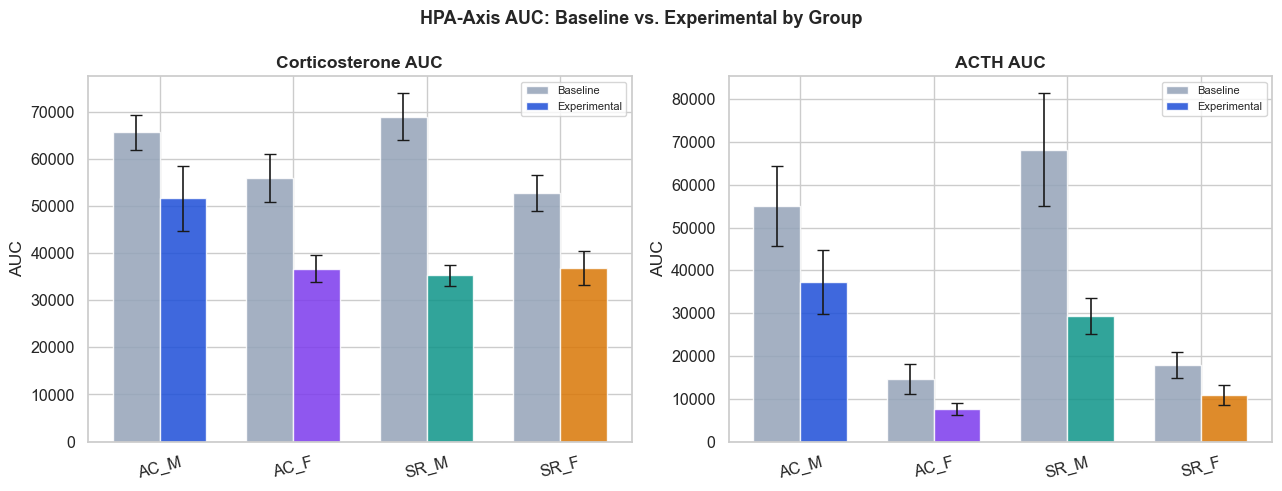

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('HPA-Axis AUC: Baseline vs. Experimental by Group', fontsize=13, fontweight='bold')

for ax, (hormone, (bsln_col, exp_col)) in zip(axes, auc_pairs.items()):
    means_b = [df[df['Group']==g][bsln_col].mean() for g in groups_order]
    means_e = [df[df['Group']==g][exp_col].mean()  for g in groups_order]
    sems_b  = [df[df['Group']==g][bsln_col].sem()  for g in groups_order]
    sems_e  = [df[df['Group']==g][exp_col].sem()   for g in groups_order]

    b1 = ax.bar(x - width/2, means_b, width, yerr=sems_b, capsize=4,
                label='Baseline', color='#94A3B8', alpha=0.85, error_kw={'linewidth':1.2})
    b2 = ax.bar(x + width/2, means_e, width, yerr=sems_e, capsize=4,
                label='Experimental', color=group_colors, alpha=0.85, error_kw={'linewidth':1.2})

    ax.set_title(hormone, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(groups_order, rotation=15)
    ax.set_ylabel('AUC')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_auc.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. HPA-Axis: Hormone Time-Course Profiles

Corticosterone and ACTH measured at Diurnal PM, 0 min, 30 min, 60 min, 90 min, and 150 min post-stressor.

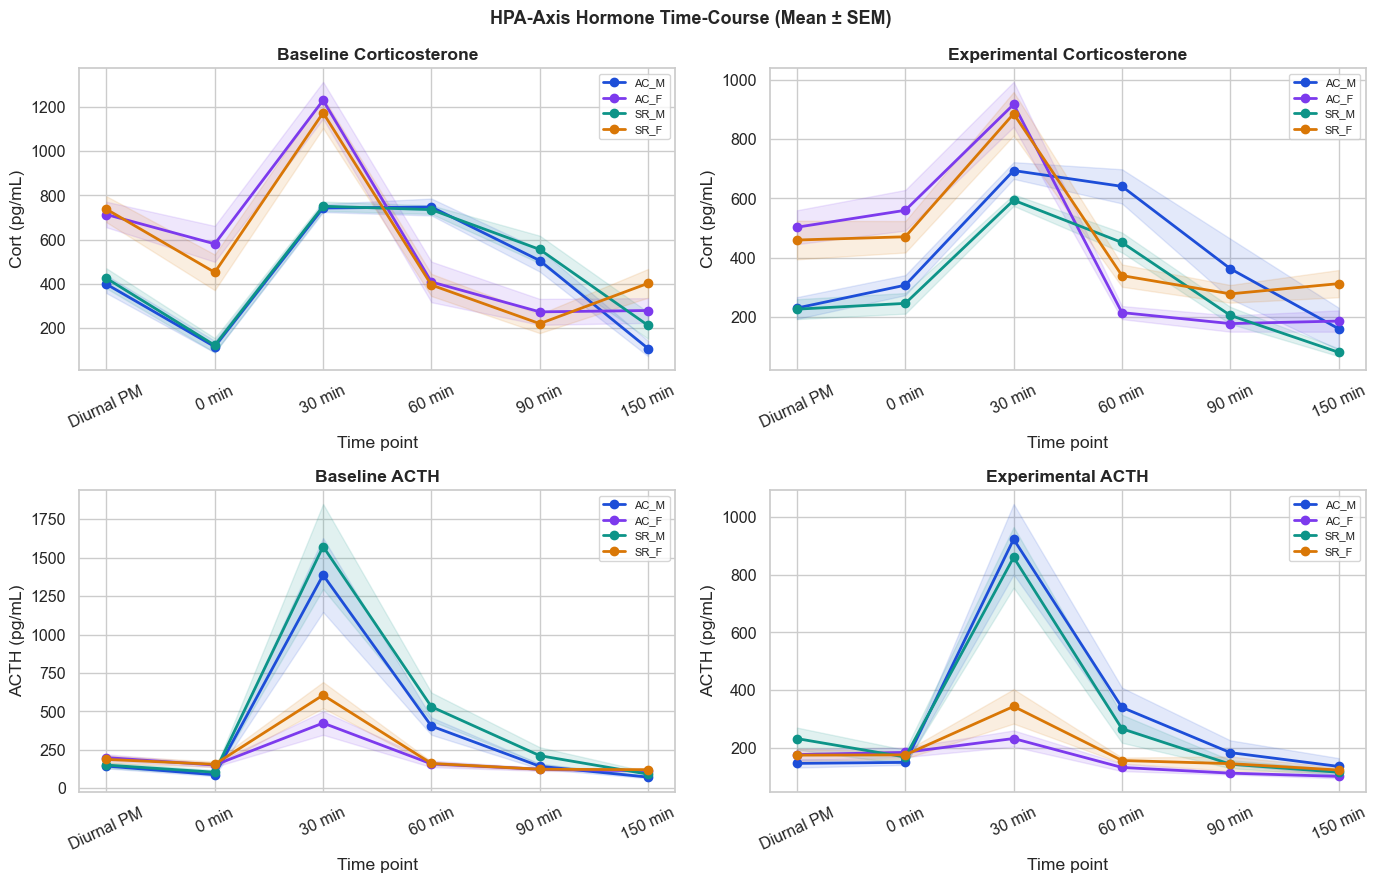

In [10]:
timepoints = ['Diurnal PM', '0 min', '30 min', '60 min', '90 min', '150 min']

cort_bsln_cols = ['Baseline Cort Diurnal PM','Baseline Cort Diurnal AM = 0 min',
                   'Baseline Cort 30 min','Baseline Cort 60 min',
                   'Baseline Cort 90 min','Baseline Cort 150 min']
cort_exp_cols  = ['Exp. Cort Diurnal PM','Exp. Cort Diurnal AM = 0 min',
                   'Exp. Cort 30 min','Exp. Cort 60 min',
                   'Exp. Cort 90 min','Exp. Cort 150 min']
acth_bsln_cols = ['Baseline ACTH Diurnal PM','Baseline ACTH Diurnal AM = 0 min',
                   'Baseline ACTH 30 min','Baseline ACTH 60 min',
                   'Baseline ACTH 90 min','Baseline ACTH 150 min']
acth_exp_cols  = ['Exp. ACTH Diurnal PM','Exp. ACTH Diurnal AM = 0 min',
                   'Exp. ACTH 30 min','Exp. ACTH 60 min',
                   'Exp. ACTH 90 min','Exp. ACTH 150 min']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('HPA-Axis Hormone Time-Course (Mean ± SEM)', fontsize=13, fontweight='bold')

def plot_timecourse(ax, cols, title, ylabel):
    for g in groups_order:
        sub = df[df['Group']==g]
        means = [sub[c].mean() for c in cols]
        sems  = [sub[c].sem()  for c in cols]
        ax.plot(timepoints, means, marker='o', label=g, color=C[g], linewidth=2)
        ax.fill_between(timepoints,
                        [m-s for m,s in zip(means,sems)],
                        [m+s for m,s in zip(means,sems)],
                        color=C[g], alpha=0.12)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Time point')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(fontsize=8)

plot_timecourse(axes[0,0], cort_bsln_cols, 'Baseline Corticosterone', 'Cort (pg/mL)')
plot_timecourse(axes[0,1], cort_exp_cols,  'Experimental Corticosterone', 'Cort (pg/mL)')
plot_timecourse(axes[1,0], acth_bsln_cols, 'Baseline ACTH', 'ACTH (pg/mL)')
plot_timecourse(axes[1,1], acth_exp_cols,  'Experimental ACTH', 'ACTH (pg/mL)')

plt.tight_layout()
plt.savefig('fig_timecourse.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Open-Field Behavior

Two open-field (OF) measures assessed at baseline and experimentally:
- **Total Distance (m)** — locomotor activity
- **Time in Outer Squares (s)** — anxiety-like behavior (more time in outer = higher anxiety)

In [11]:
of_pairs = {
    'Total Distance (m)':        ('Baseline TL Distance (m) OF', 'Exp. TL Distance (m) OF'),
    'Time in Outer Squares (s)': ('Baseline Time in outer squares (s)', 'Exp. Time in outer squares (s)'),
}

print('Open-Field Behavior — Mean (SD) by Group')
of_rows = []
for measure, (bsln_col, exp_col) in of_pairs.items():
    for g in groups_order:
        sub = df[df['Group']==g]
        b = sub[bsln_col].dropna()
        e = sub[exp_col].dropna()
        of_rows.append({
            'Measure': measure, 'Group': g,
            'Baseline Mean (SD)': f"{b.mean():.2f} ({b.std():.2f})" if len(b) else 'N/A',
            'Exp. Mean (SD)':     f"{e.mean():.2f} ({e.std():.2f})" if len(e) else 'N/A',
            'Δ (Exp−BSLN)':      f"{(e.mean()-b.mean()):.2f}" if len(b) and len(e) else 'N/A',
        })
display(pd.DataFrame(of_rows).set_index(['Measure','Group']))

print('\n── Wilcoxon signed-rank: Baseline vs Experimental OF (within group) ──')
for measure, (bsln_col, exp_col) in of_pairs.items():
    for g in groups_order:
        sub = df[df['Group']==g][[bsln_col, exp_col]].dropna()
        if len(sub) >= 4:
            stat, p = stats.wilcoxon(sub[bsln_col], sub[exp_col])
            print(f'  {measure:30s} | {g:6s} | W={stat:.0f}, p={p:.3f}')

Open-Field Behavior — Mean (SD) by Group


Baseline Mean (SD)  Exp. Mean (SD)  \
Measure                   Group                                      
Total Distance (m)        AC_M       35.53 (10.41)    48.40 (9.43)   
                          AC_F       56.08 (11.24)    53.66 (4.87)   
                          SR_M        40.47 (9.99)   48.27 (10.08)   
                          SR_F        54.63 (6.98)    55.32 (8.25)   
Time in Outer Squares (s) AC_M      573.96 (19.37)  493.27 (47.52)   
                          AC_F      548.96 (21.23)  476.19 (23.64)   
                          SR_M      577.40 (14.12)  509.96 (34.40)   
                          SR_F      548.46 (25.80)  479.04 (23.00)   

                                Δ (Exp−BSLN)  
Measure                   Group               
Total Distance (m)        AC_M         12.87  
                          AC_F         -2.42  
                          SR_M          7.81  
                          SR_F          0.69  
Time in Outer Squares (s) AC_M        -80.68  
                          AC_F        -72.77  
                          SR_M        -67.44  
                          SR_F        -69.42


── Wilcoxon signed-rank: Baseline vs Experimental OF (within group) ──
  Total Distance (m)             | AC_M   | W=8, p=0.002
  Total Distance (m)             | AC_F   | W=38, p=0.229
  Total Distance (m)             | SR_M   | W=17, p=0.006
  Total Distance (m)             | SR_F   | W=67, p=0.980
  Time in Outer Squares (s)      | AC_M   | W=1, p=0.000
  Time in Outer Squares (s)      | AC_F   | W=1, p=0.000
  Time in Outer Squares (s)      | SR_M   | W=2, p=0.000
  Time in Outer Squares (s)      | SR_F   | W=0, p=0.000


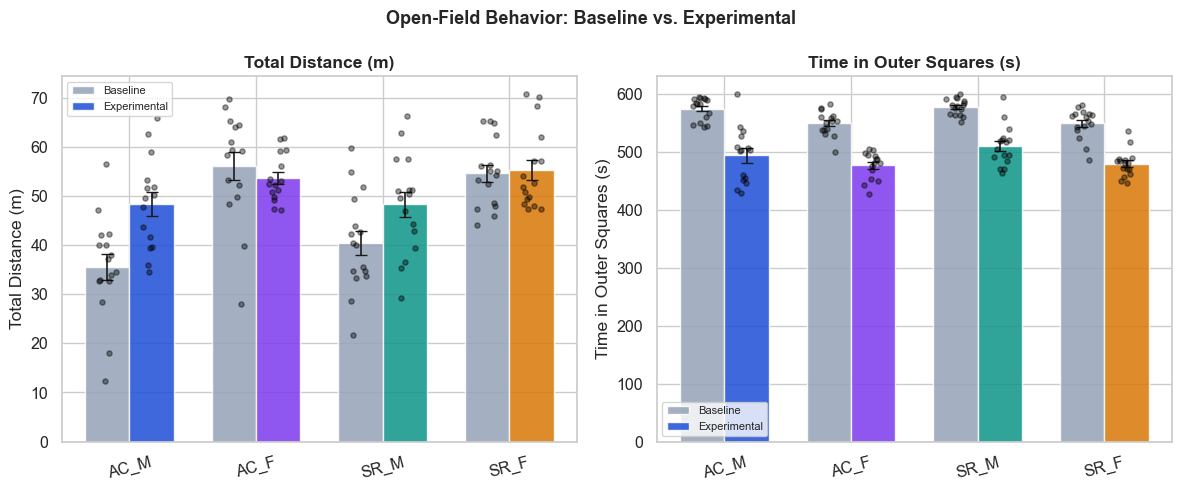

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Open-Field Behavior: Baseline vs. Experimental', fontsize=13, fontweight='bold')

for ax, (measure, (bsln_col, exp_col)) in zip(axes, of_pairs.items()):
    means_b = [df[df['Group']==g][bsln_col].mean() for g in groups_order]
    means_e = [df[df['Group']==g][exp_col].mean()  for g in groups_order]
    sems_b  = [df[df['Group']==g][bsln_col].sem()  for g in groups_order]
    sems_e  = [df[df['Group']==g][exp_col].sem()   for g in groups_order]

    ax.bar(x - width/2, means_b, width, yerr=sems_b, capsize=4,
           label='Baseline', color='#94A3B8', alpha=0.85, error_kw={'linewidth':1.2})
    ax.bar(x + width/2, means_e, width, yerr=sems_e, capsize=4,
           label='Experimental', color=group_colors, alpha=0.85, error_kw={'linewidth':1.2})

    # Overlay individual points
    for i, g in enumerate(groups_order):
        for col_off, col in [(-width/2, bsln_col), (+width/2, exp_col)]:
            vals = df[df['Group']==g][col].dropna()
            ax.scatter(np.full(len(vals), i+col_off) + np.random.uniform(-0.08, 0.08, len(vals)),
                       vals, color='black', s=14, alpha=0.4, zorder=3)

    ax.set_title(measure, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(groups_order, rotation=15)
    ax.set_ylabel(measure)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_openfield.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Heatmap — Measure Summary by Group

Two heatmaps:
1. **Experimental means** — all key measures across the four Condition × Sex groups (z-scored within each measure for cross-domain comparison).
2. **Δ Change (Exp − Baseline)** — direction and magnitude of change from baseline to experimental phase.

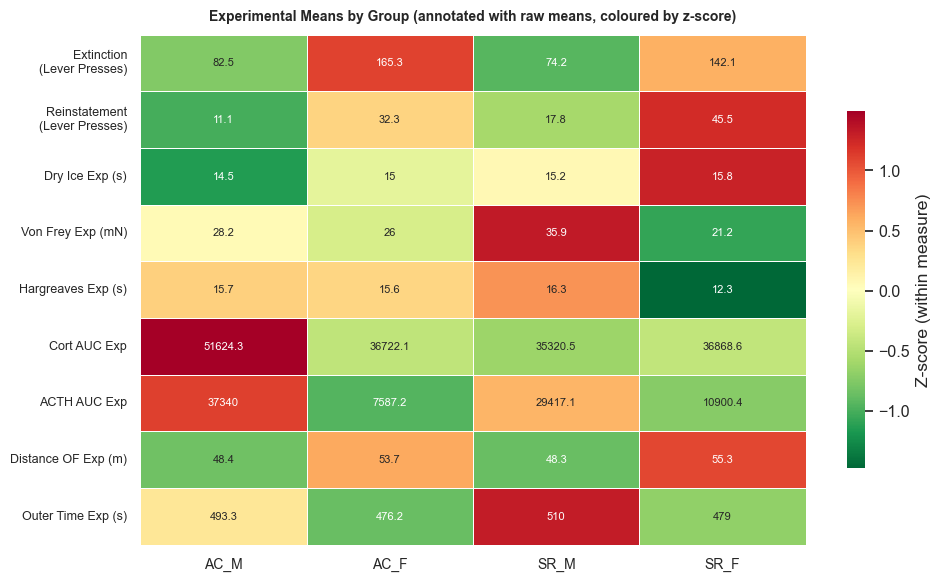

In [13]:
# ── 8a. Experimental means heatmap (z-scored) ─────────────────────────────────
hm_measures = {
    'Extinction\n(Lever Presses)':   'Extinction 1 (Active Lever Presses)',
    'Reinstatement\n(Lever Presses)':'Footshock Reinstatement (Active Lever Presses)',
    'Dry Ice Exp (s)':               'Dry Ice Exp',
    'Von Frey Exp (mN)':             'Von Exp force in mN',
    'Hargreaves Exp (s)':            'Hargreaves Exp',
    'Cort AUC Exp':                  'Exp. Cort AUC',
    'ACTH AUC Exp':                  'Exp. ACTH AUC',
    'Distance OF Exp (m)':           'Exp. TL Distance (m) OF',
    'Outer Time Exp (s)':            'Exp. Time in outer squares (s)',
}

hm_exp = pd.DataFrame(
    {lbl: {g: df[df['Group']==g][col].mean() for g in groups_order}
     for lbl, col in hm_measures.items()}
).T

# Z-score across groups for each measure
hm_exp_z = hm_exp.apply(lambda row: (row - row.mean()) / (row.std() + 1e-9), axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    hm_exp_z,
    ax=ax,
    cmap='RdYlGn_r',   # red=high, green=low (more pain/stress = red)
    annot=hm_exp.round(1),
    fmt='g',
    annot_kws={'size': 8},
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Z-score (within measure)', 'shrink': 0.7}
)
ax.set_title('Experimental Means by Group (annotated with raw means, coloured by z-score)',
             fontsize=10, fontweight='bold', pad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('fig_heatmap_exp.png', dpi=150, bbox_inches='tight')
plt.show()

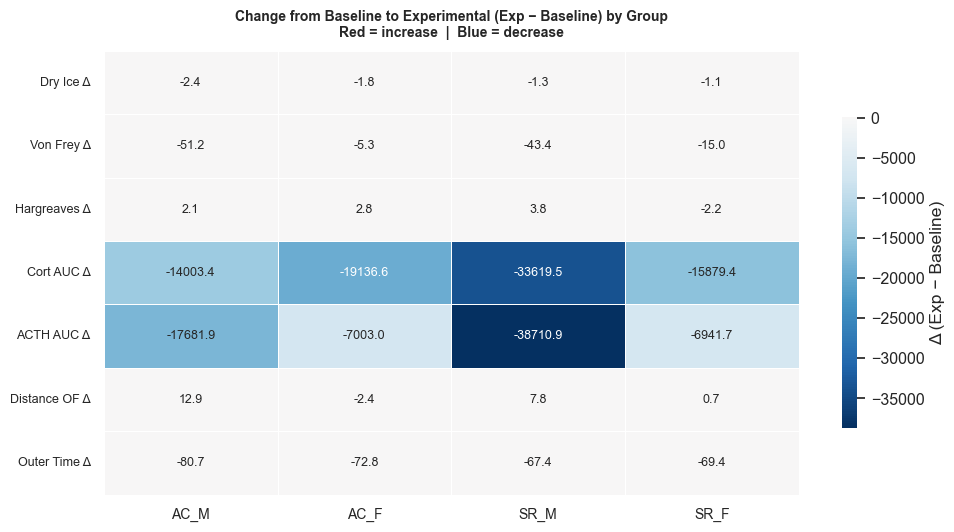

In [14]:
# ── 8b. Delta change heatmap ──────────────────────────────────────────────────
delta_measures = {
    'Dry Ice Δ':       ('Dry Ice BSLN',                    'Dry Ice Exp'),
    'Von Frey Δ':      ('Von BSLN force in mN',            'Von Exp force in mN'),
    'Hargreaves Δ':    ('Hargreaves BSLN',                  'Hargreaves Exp'),
    'Cort AUC Δ':      ('Baseline Cort AUC',               'Exp. Cort AUC'),
    'ACTH AUC Δ':      ('Baseline ACTH AUC',               'Exp. ACTH AUC'),
    'Distance OF Δ':   ('Baseline TL Distance (m) OF',     'Exp. TL Distance (m) OF'),
    'Outer Time Δ':    ('Baseline Time in outer squares (s)', 'Exp. Time in outer squares (s)'),
}

delta_data = {}
for lbl, (bsln_col, exp_col) in delta_measures.items():
    delta_data[lbl] = {
        g: df[df['Group']==g][exp_col].mean() - df[df['Group']==g][bsln_col].mean()
        for g in groups_order
    }

hm_delta = pd.DataFrame(delta_data).T

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(
    hm_delta,
    ax=ax,
    cmap='RdBu_r',   # red=increase, blue=decrease
    center=0,
    annot=True,
    fmt='.1f',
    annot_kws={'size': 9},
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Δ (Exp − Baseline)', 'shrink': 0.7}
)
ax.set_title('Change from Baseline to Experimental (Exp − Baseline) by Group\nRed = increase  |  Blue = decrease',
             fontsize=10, fontweight='bold', pad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('fig_heatmap_delta.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Baseline vs. Experimental Δ Change Summary

Dot-plot showing the mean Δ change (Exp − Baseline) with 95% CI for each measure and group.

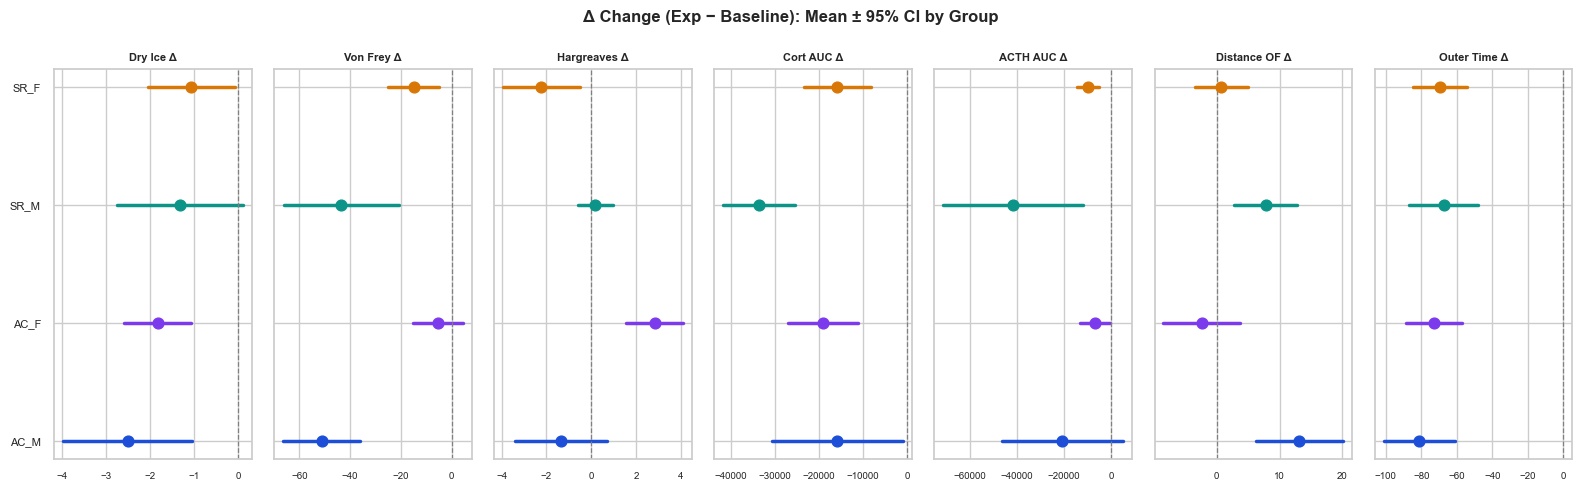

In [15]:
def mean_ci(series):
    s = series.dropna()
    if len(s) < 2:
        return np.nan, np.nan, np.nan
    m   = s.mean()
    sem = s.sem()
    ci  = 1.96 * sem
    return m, m-ci, m+ci

# Build delta series per rat
df2 = df.copy()
for lbl, (bc, ec) in delta_measures.items():
    df2[f'delta_{lbl}'] = df2[ec] - df2[bc]

delta_cols = [f'delta_{lbl}' for lbl in delta_measures]
delta_labels = list(delta_measures.keys())

fig, axes = plt.subplots(1, len(delta_measures), figsize=(16, 5))
fig.suptitle('Δ Change (Exp − Baseline): Mean ± 95% CI by Group', fontsize=12, fontweight='bold')

for ax, (lbl, dcol) in zip(axes, zip(delta_labels, delta_cols)):
    for i, g in enumerate(groups_order):
        m, lo, hi = mean_ci(df2[df2['Group']==g][dcol])
        ax.plot([lo, hi], [i, i], color=C[g], linewidth=2.5)
        ax.scatter(m, i, color=C[g], s=60, zorder=4)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.9)
    ax.set_yticks(range(len(groups_order)))
    ax.set_yticklabels(groups_order if ax == axes[0] else [], fontsize=8)
    ax.set_title(lbl, fontsize=8, fontweight='bold')
    ax.tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.savefig('fig_delta.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary Table & Export

In [16]:
# ── Build comprehensive summary table ─────────────────────────────────────────
all_measures = {
    'Lever: Extinction (presses)':      ('Extinction 1 (Active Lever Presses)', None),
    'Lever: Reinstatement (presses)':   ('Footshock Reinstatement (Active Lever Presses)', None),
    'Pain: Dry Ice BSLN (s)':           ('Dry Ice BSLN', None),
    'Pain: Dry Ice Exp (s)':            ('Dry Ice Exp', None),
    'Pain: Von Frey BSLN (mN)':         ('Von BSLN force in mN', None),
    'Pain: Von Frey Exp (mN)':          ('Von Exp force in mN', None),
    'Pain: Hargreaves BSLN (s)':        ('Hargreaves BSLN', None),
    'Pain: Hargreaves Exp (s)':         ('Hargreaves Exp', None),
    'HPA: Cort AUC BSLN':              ('Baseline Cort AUC', None),
    'HPA: Cort AUC Exp':               ('Exp. Cort AUC', None),
    'HPA: ACTH AUC BSLN':             ('Baseline ACTH AUC', None),
    'HPA: ACTH AUC Exp':              ('Exp. ACTH AUC', None),
    'OF: Distance BSLN (m)':           ('Baseline TL Distance (m) OF', None),
    'OF: Distance Exp (m)':            ('Exp. TL Distance (m) OF', None),
    'OF: Outer Time BSLN (s)':         ('Baseline Time in outer squares (s)', None),
    'OF: Outer Time Exp (s)':          ('Exp. Time in outer squares (s)', None),
}

summary_rows = []
for measure_lbl, (col, _) in all_measures.items():
    row = {'Measure': measure_lbl}
    for g in groups_order:
        sub = df[df['Group']==g][col].dropna()
        row[f'{g} Mean'] = round(sub.mean(), 2) if len(sub) else np.nan
        row[f'{g} SD']   = round(sub.std(),  2) if len(sub) else np.nan
        row[f'{g} n']    = len(sub)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Measure')
print('HDP00049 — Full Secondary Analysis Summary Table')
display(summary_df)

summary_df.to_csv('HDP00049_summary.csv')
print('\nExported: HDP00049_summary.csv')
print('\nFigures saved:')
for f in ['fig_sample','fig_lever','fig_pain','fig_auc','fig_timecourse',
           'fig_openfield','fig_heatmap_exp','fig_heatmap_delta','fig_delta']:
    print(f'  {f}.png')

HDP00049 — Full Secondary Analysis Summary Table


,AC_M Mean,AC_M SD,AC_M n,AC_F Mean,AC_F SD,AC_F n,SR_M Mean,SR_M SD,SR_M n,SR_F Mean,SR_F SD,SR_F n
Measure,,,,,,,,,,,,
Lever: Extinction (presses),82.47,41.73,15,165.33,115.66,15,74.19,32.30,16,142.12,85.22,16
Lever: Reinstatement (presses),11.07,8.57,15,32.33,22.31,15,17.75,14.81,16,45.50,40.60,16
Pain: Dry Ice BSLN (s),16.97,1.59,16,16.86,1.67,15,16.48,1.94,16,16.84,1.66,16
Pain: Dry Ice Exp (s),14.53,2.65,15,15.02,1.30,15,15.15,1.99,16,15.77,1.75,16
Pain: Von Frey BSLN (mN),79.35,26.20,16,31.31,17.66,15,79.31,41.14,16,36.23,21.66,16
Pain: Von Frey Exp (mN),28.19,13.15,16,25.97,17.02,15,35.92,21.33,16,21.22,5.48,16
Pain: Hargreaves BSLN (s),13.61,1.26,6,12.81,2.48,15,12.51,0.37,4,14.51,2.13,16
Pain: Hargreaves Exp (s),15.72,3.37,14,15.65,1.95,15,16.32,2.84,12,12.29,2.01,16
HPA: Cort AUC BSLN,65627.72,14608.13,16,55858.71,19657.95,15,68940.00,19797.51,16,52748.09,15215.77,16



Exported: HDP00049_summary.csv

Figures saved:
  fig_sample.png
  fig_lever.png
  fig_pain.png
  fig_auc.png
  fig_timecourse.png
  fig_openfield.png
  fig_heatmap_exp.png
  fig_heatmap_delta.png
  fig_delta.png
